In [18]:
# task 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.makedirs('charts', exist_ok=True)

# loading the dataset
df = pd.read_csv("train.csv")

#display first 5 rows
df.head()

# Converting Order Date and Ship Date into datetime objects
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

# Checking data types
df.dtypes

# Creating useful time-based features
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Week Number"] = df["Order Date"].dt.isocalendar().week
df["Day of Week"] = df["Order Date"].dt.day_name()
df["Quarter"] = df["Order Date"].dt.quarter

# Creating seasons manually
def get_season(month):

    if month in [12, 1, 2]:
        return "Winter"

    elif month in [3, 4, 5]:
        return "Spring"

    elif month in [6, 7, 8]:
        return "Summer"

    else:
        return "Autumn"

df["Season"] = df["Month"].apply(get_season)
df.head()

# Checking missing values
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

# Checking duplicate rows
duplicate_rows = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_rows)

# Checking all column data types
df.info()

# Creating daily sales dataset
daily_sales = (
    df.groupby("Order Date")["Sales"]
      .sum()
      .reset_index()
)
daily_sales.head()

# Creating weekly sales dataset
weekly_sales = (
    df.groupby(
        pd.Grouper(
            key="Order Date",
            freq="W"
        )
    )["Sales"]
    .sum()
    .reset_index()
)
weekly_sales.head()

# Creating monthly sales dataset
monthly_sales = (
    df.groupby(
        pd.Grouper(
            key="Order Date",
            freq="ME"
        )
    )["Sales"]
    .sum()
    .reset_index()
)
monthly_sales.head()

Number of duplicate rows: 0
<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   str           
 2   Order Date     9800 non-null   datetime64[us]
 3   Ship Date      9800 non-null   datetime64[us]
 4   Ship Mode      9800 non-null   str           
 5   Customer ID    9800 non-null   str           
 6   Customer Name  9800 non-null   str           
 7   Segment        9800 non-null   str           
 8   Country        9800 non-null   str           
 9   City           9800 non-null   str           
 10  State          9800 non-null   str           
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   str           
 13  Product ID     9800 non-null   str           
 14  Category       9800 non-null   str           
 15  Sub-

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


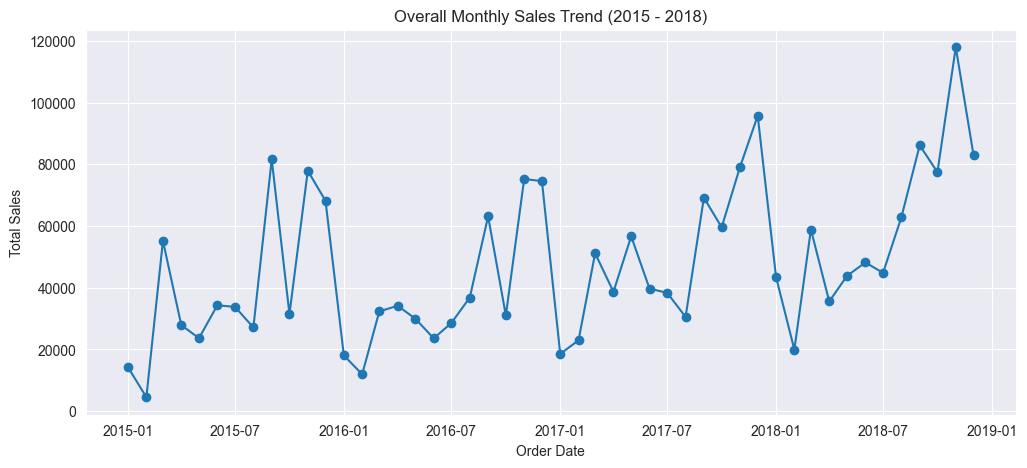

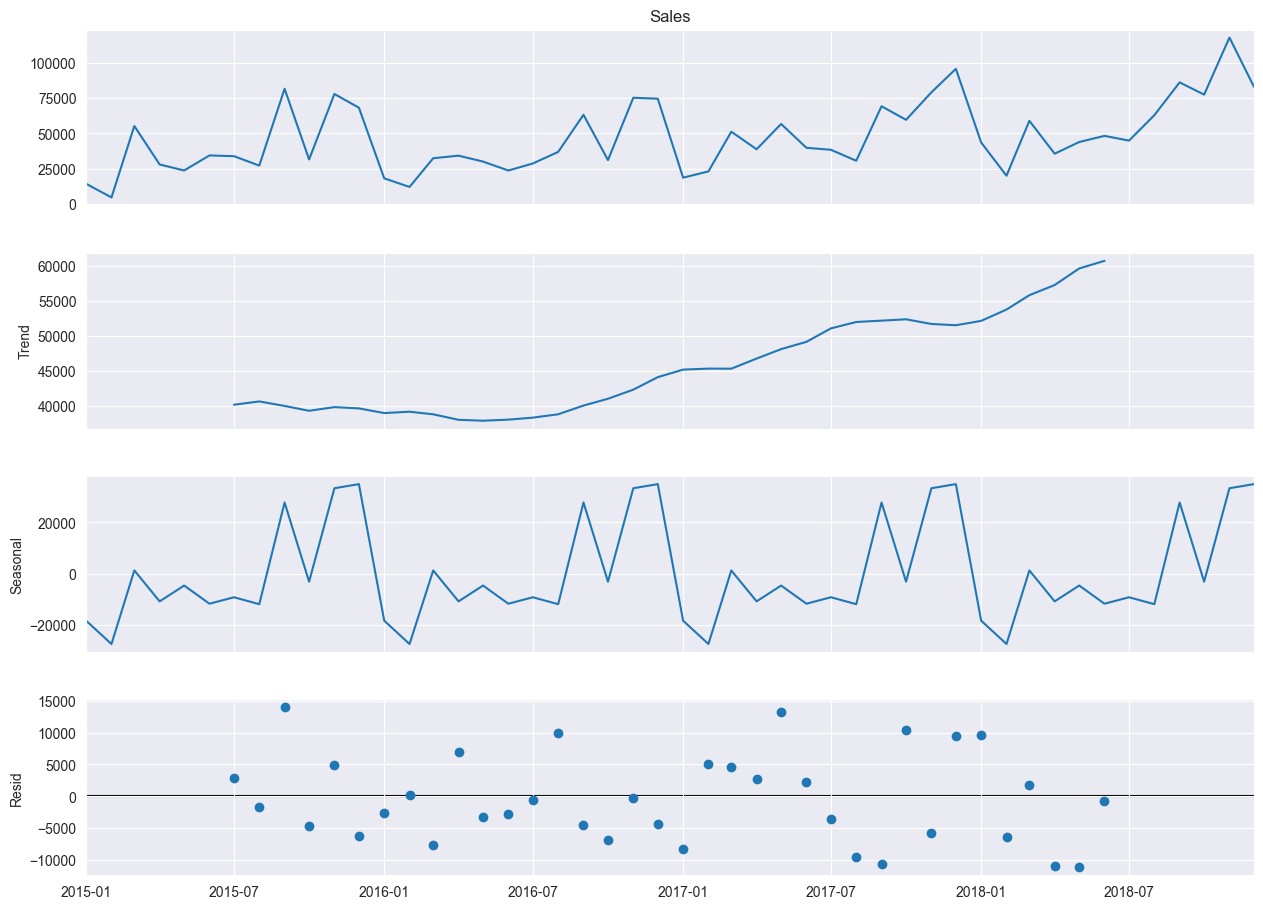


OBSERVATIONS
1. The overall sales trend increases gradually from 2015 to 2018, showing business growth.
2. The seasonal component repeats a similar pattern every year, indicating strong yearly seasonality.
3. The highest residual variations are observed in September 2015, May 2017, May 2018, April 2018 and September 2017.
4. Since the ADF test gives a p-value less than 0.05, the monthly sales series is already stationary and no differencing is required.

Top 5 months with highest residual noise:
Order Date
2015-09-01    13970.933082
2017-05-01    13193.079793
2018-05-01    11157.549320
2018-04-01    10916.959724
2017-09-01    10642.715643
Name: resid, dtype: float64

ADF TEST BEFORE DIFFERENCING
ADF Statistic : -4.416136761430769
P-value : 0.00027791039276670623

Critical Values
1% : -3.5778480370438146
5% : -2.925338105429433
10% : -2.6007735310095064

Meaning of Stationarity:
A stationary time series has almost constant mean and variance over time.
Most forecasting models work bette

In [30]:
# TASK 2 : TIME SERIES ANALYSIS & DECOMPOSITION

# Importing required libraries
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# Creating monthly sales time series

# Grouping sales month-wise
monthly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="MS"))["Sales"]
      .sum()
)

# Plotting overall monthly sales trend

plt.figure(figsize=(12,5))

plt.plot(monthly_sales, marker="o")

plt.title("Overall Monthly Sales Trend (2015 - 2018)")
plt.xlabel("Order Date")
plt.ylabel("Total Sales")
plt.grid(True)
plt.savefig("charts/1_monthly_sales_trend.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

# Time Series Decomposition

# Breaking the series into Trend, Seasonal and Residual parts
decomposition = seasonal_decompose(
    monthly_sales,
    model="additive",
    period=12
)

# Plotting all four components
fig = decomposition.plot()
fig.set_size_inches(14,10)
# Save and show
fig.savefig("charts/2_time_series_decomposition.png",
            dpi=300,
            bbox_inches='tight')
plt.show()

# Writing observations

print("\n"+"="*20)
print("OBSERVATIONS")
print("="*20)

print("1. The overall sales trend increases gradually from 2015 to 2018, showing business growth.")
print("2. The seasonal component repeats a similar pattern every year, indicating strong yearly seasonality.")
print("3. The highest residual variations are observed in September 2015, May 2017, May 2018, April 2018 and September 2017.")
print("4. Since the ADF test gives a p-value less than 0.05, the monthly sales series is already stationary and no differencing is required.")
# Finding months having highest residual values
residual = decomposition.resid.dropna()
highest_noise = residual.abs().sort_values(ascending=False).head(5)
print("\nTop 5 months with highest residual noise:")
print(highest_noise)

# Augmented Dickey Fuller (ADF) Test

print("\n" + "="*50)
print("ADF TEST BEFORE DIFFERENCING")
print("="*50)
adf_result = adfuller(monthly_sales)
print("ADF Statistic :", adf_result[0])
print("P-value :", adf_result[1])
print("\nCritical Values")
for key, value in adf_result[4].items():
    print(key, ":", value)

# Explaining stationarity in simple language
print("\nMeaning of Stationarity:")
print("A stationary time series has almost constant mean and variance over time.")
print("Most forecasting models work better when the data is stationary.")

# Checking if differencing is required
if adf_result[1] < 0.05:
    print("\nResult : Since p-value is less than 0.05, the series is stationary.")
    print("Differencing is NOT required.")

else:
    print("\nResult : Since p-value is greater than 0.05, the series is not stationary.")
    print("Applying first-order differencing...\n")

    # Applying first-order differencing

    monthly_sales_diff = monthly_sales.diff().dropna()

    # Plotting differenced series
    plt.figure(figsize=(12,5))
    plt.plot(monthly_sales_diff, marker="o")
    plt.title("Monthly Sales After First Order Differencing")
    plt.xlabel("Order Date")
    plt.ylabel("Differenced Sales")
    plt.grid(True)
    plt.show()

    # ADF Test After Differencing

    print("="*70)
    print("ADF TEST AFTER DIFFERENCING")
    print("="*70)
    adf_result_diff = adfuller(monthly_sales_diff)
    print("ADF Statistic :", adf_result_diff[0])
    print("P-value :", adf_result_diff[1])
    print("\nCritical Values")
    for key, value in adf_result_diff[4].items():
        print(key, ":", value)
    if adf_result_diff[1] < 0.05:
        print("\nAfter differencing, the series has become stationary.")
    else:
        print("\nThe series is still non-stationary.")

Number of training months : 45
Number of testing months  : 3

SARIMA MODEL RESULTS
----------------------------------------
MAE  : 19244.49
RMSE : 19950.07
MAPE : 20.53 %

Actual Sales for Last 3 Months
Order Date
2018-10-31     77448.1312
2018-11-30    117938.1550
2018-12-31     83030.3888
Freq: ME, Name: Sales, dtype: float64

Forecasted Sales for Last 3 Months
2018-10-31    60331.792073
2018-11-30    91458.220227
2018-12-31    97167.570936
Freq: ME, Name: predicted_mean, dtype: float64

95% Confidence Interval
             lower Sales    upper Sales
2018-10-31  33867.663882   86795.920264
2018-11-30  64294.739760  118621.700695
2018-12-31  69727.828580  124607.313291


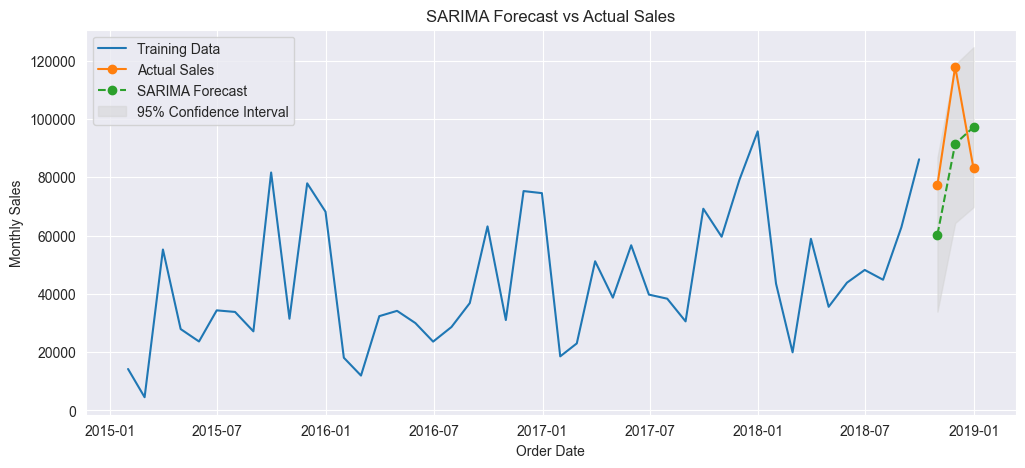

In [20]:
# TASK 3 : MODEL 1 - SARIMA SALES FORECASTING
import warnings
warnings.filterwarnings("ignore")
# Importing required libraries
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Preparing monthly sales data
# Grouping total sales month-wise
monthly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
      .sum()
)

# Keeping last 3 months for testing
train = monthly_sales[:-3]
test = monthly_sales[-3:]
print("="*70)
print("Number of training months :", len(train))
print("Number of testing months  :", len(test))
print("="*70)

# Building the SARIMA model

# Chosen Parameters
# order = (1,1,1)
# seasonal_order = (1,1,1,12)
#
# Why?
# d = 1 helps remove trend if present.
# Seasonal period is 12 because data is monthly.
# (1,1,1) is a simple and commonly used starting model.
sarima_model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_result = sarima_model.fit()

# Forecasting next 3 months

forecast = sarima_result.get_forecast(steps=3)
forecast_values = forecast.predicted_mean
confidence_interval = forecast.conf_int()
# Calculating Evaluation Metrics

mae = mean_absolute_error(test, forecast_values)
rmse = np.sqrt(mean_squared_error(test, forecast_values))
mape = np.mean(np.abs((test - forecast_values) / test)) * 100

# Printing Results

print("\nSARIMA MODEL RESULTS")
print("-"*40)
print("MAE  :", round(mae,2))
print("RMSE :", round(rmse,2))
print("MAPE :", round(mape,2), "%")
print("\nActual Sales for Last 3 Months")
print(test)
print("\nForecasted Sales for Last 3 Months")
print(forecast_values)
print("\n95% Confidence Interval")
print(confidence_interval)

# Plotting Actual vs Forecast

plt.figure(figsize=(12,5))
plt.plot(train.index, train, label="Training Data")
plt.plot(test.index, test,
         marker="o",
         label="Actual Sales")
plt.plot(forecast_values.index,
         forecast_values,
         marker="o",
         linestyle="--",
         label="SARIMA Forecast")
plt.fill_between(
    confidence_interval.index,
    confidence_interval.iloc[:,0],
    confidence_interval.iloc[:,1],
    color="lightgray",
    alpha=0.5,
    label="95% Confidence Interval"
)
plt.title("SARIMA Forecast vs Actual Sales")
plt.xlabel("Order Date")
plt.ylabel("Monthly Sales")
plt.legend()
plt.grid(True)
plt.show()

# Saving results for comparison with other models

sarima_mae = mae
sarima_rmse = rmse
sarima_mape = mape

sarima_forecast = forecast_values
#"The dataset contains only 48 monthly observations. Because of the limited number of seasonal cycles, statsmodels
#displayed a warning while estimating the initial seasonal parameters. However, the model successfully converged and generated forecasts."

16:02:23 - cmdstanpy - INFO - Chain [1] start processing


Number of training months : 45
Number of testing months  : 3


16:02:24 - cmdstanpy - INFO - Chain [1] done processing



Prophet Model Results
--------------------------------------------------
MAE  : 20250.79
RMSE : 22318.41
MAPE : 21.86 %

Actual Sales for Last 3 Months
           ds            y
45 2018-10-31   77448.1312
46 2018-11-30  117938.1550
47 2018-12-31   83030.3888

Forecasted Sales for Next 3 Months
           ds          yhat
45 2018-10-31  51318.943858
46 2018-11-30  90325.654784
47 2018-12-31  90041.084479


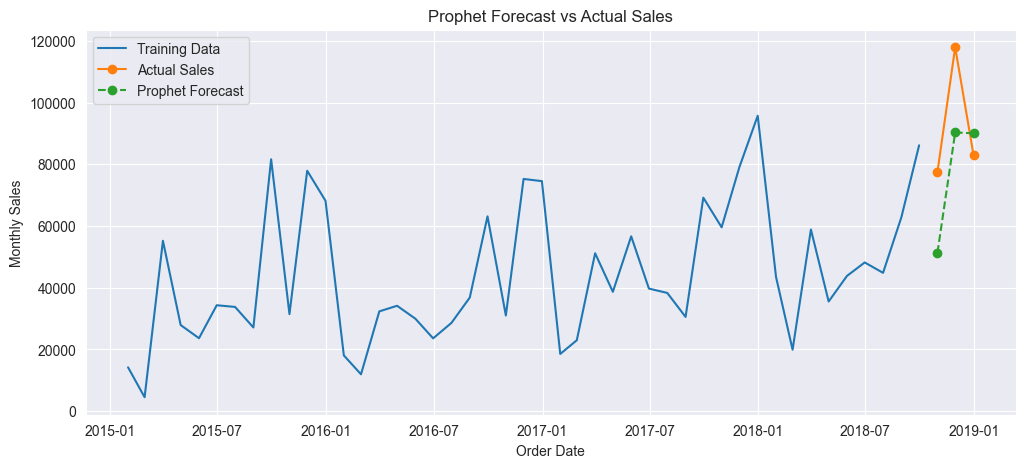

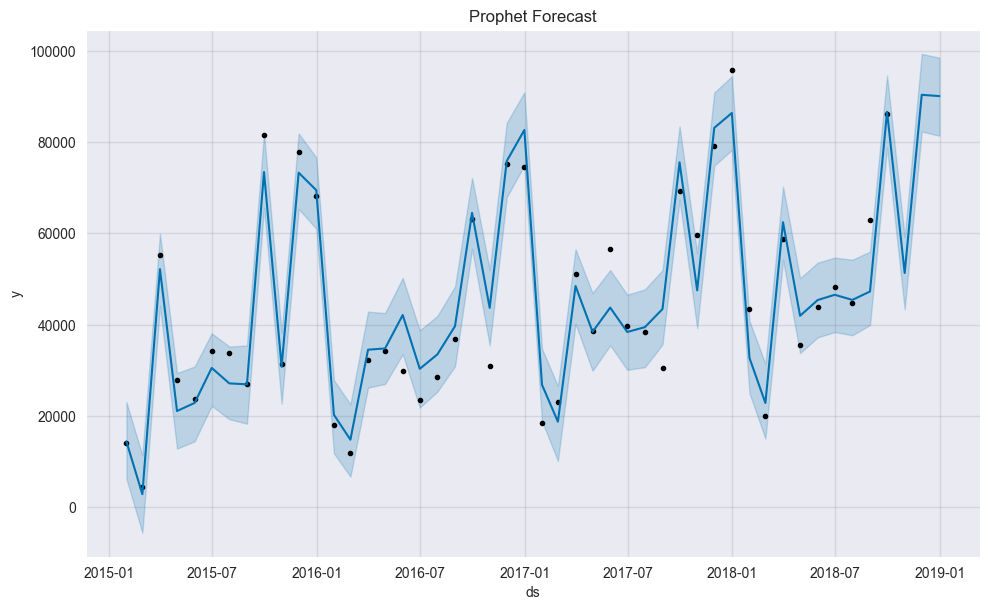

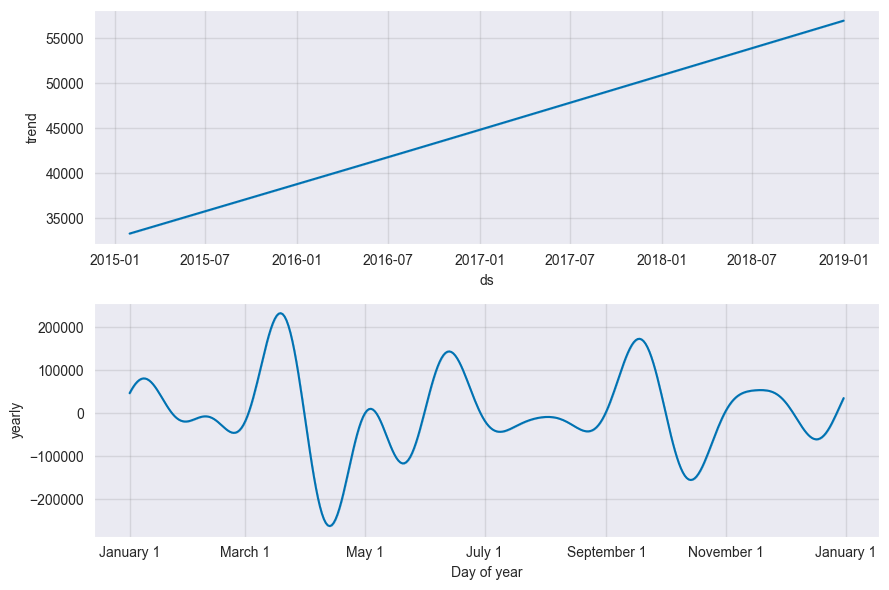


Seasonality Interpretation
--------------------------------------------------
1. The trend plot shows the long-term growth in monthly sales.
2. The yearly seasonality plot shows how sales change throughout the year.
3. Weekly seasonality is disabled because our data is aggregated monthly.


In [21]:
# TASK 3 : MODEL 2 - Facebook Prophet
# Importing required libraries

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Preparing the data for Prophet

prophet_data = monthly_sales.reset_index()

prophet_data.columns = ["ds", "y"]

# Keeping last 3 months for testing

train_prophet = prophet_data[:-3]

test_prophet = prophet_data[-3:]

print("Number of training months :", len(train_prophet))
print("Number of testing months  :", len(test_prophet))

# Creating the Prophet model

# Prophet automatically captures trend and seasonality.
# It works with two columns:
# ds -> Date
# y  -> Sales

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

# Training the model

prophet_model.fit(train_prophet)

# Creating future dates for next 3 months

future = prophet_model.make_future_dataframe(
    periods=3,
    freq="ME"
)

# Predicting future sales

forecast = prophet_model.predict(future)

# Taking only the last 3 predicted months

forecast_values = forecast[["ds", "yhat"]].tail(3)

# Calculating evaluation metrics

mae = mean_absolute_error(
    test_prophet["y"],
    forecast_values["yhat"]
)

rmse = np.sqrt(
    mean_squared_error(
        test_prophet["y"],
        forecast_values["yhat"]
    )
)

mape = np.mean(
    np.abs(
        (test_prophet["y"] - forecast_values["yhat"])
        / test_prophet["y"]
    )
) * 100

# Printing the results

print("\nProphet Model Results")
print("-"*50)

print("MAE  :", round(mae,2))
print("RMSE :", round(rmse,2))
print("MAPE :", round(mape,2), "%")

print("\nActual Sales for Last 3 Months")
print(test_prophet)

print("\nForecasted Sales for Next 3 Months")
print(forecast_values)

# Plotting actual vs forecast

plt.figure(figsize=(12,5))

plt.plot(
    train_prophet["ds"],
    train_prophet["y"],
    label="Training Data"
)

plt.plot(
    test_prophet["ds"],
    test_prophet["y"],
    marker="o",
    label="Actual Sales"
)

plt.plot(
    forecast_values["ds"],
    forecast_values["yhat"],
    marker="o",
    linestyle="--",
    label="Prophet Forecast"
)

plt.title("Prophet Forecast vs Actual Sales")

plt.xlabel("Order Date")

plt.ylabel("Monthly Sales")

plt.legend()

plt.grid(True)

plt.show()

# Plotting Prophet's built-in forecast

forecast_plot = prophet_model.plot(forecast)

plt.title("Prophet Forecast")

plt.show()

# Plotting trend and seasonality

components = prophet_model.plot_components(forecast)

plt.show()

# Printing a simple interpretation

print("\nSeasonality Interpretation")
print("-"*50)

print("1. The trend plot shows the long-term growth in monthly sales.")

print("2. The yearly seasonality plot shows how sales change throughout the year.")

print("3. Weekly seasonality is disabled because our data is aggregated monthly.")

# Saving results for model comparison

prophet_mae = mae
prophet_rmse = rmse
prophet_mape = mape

prophet_forecast = forecast_values["yhat"].values

Number of training months : 42
Number of testing months  : 3

XGBoost Model Results
--------------------------------------------------
MAE  : 13915.32
RMSE : 18893.85
MAPE : 13.29 %

Actual Sales for Last 3 Months
Order Date
2018-10-31     77448.1312
2018-11-30    117938.1550
2018-12-31     83030.3888
Freq: ME, Name: Sales, dtype: float64

Predicted Sales
Order Date
2018-10-31    86465.820312
2018-11-30    86506.773438
2018-12-31    84327.281250
Freq: ME, dtype: float32


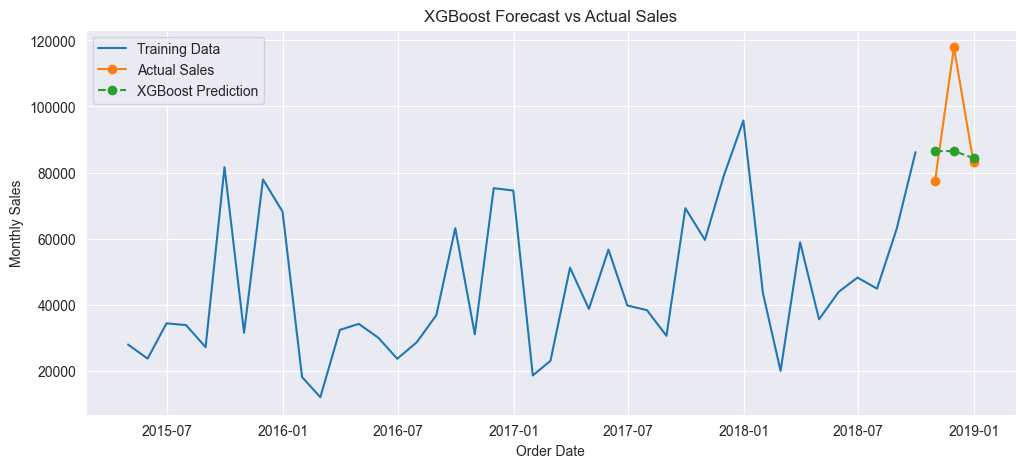


Comparison of All Forecasting Models
     Model       MAE      RMSE   MAPE  Forecast Month 1  Forecast Month 2  \
0   SARIMA  19244.49  19950.07  20.53      60331.790000      91458.220000   
1  Prophet  20250.79  22318.41  21.86      51318.940000      90325.650000   
2  XGBoost  13915.32  18893.85  13.29      86465.820312      86506.773438   

   Forecast Month 3  
0       97167.57000  
1       90041.08000  
2       84327.28125  

Recommended Model
--------------------------------------------------
Based on the evaluation metrics, the recommended model is XGBoost
XGBoost achieved the lowest MAE, RMSE and MAPE among all three models.
This indicates that it predicted monthly sales more accurately than SARIMA and Prophet.
Therefore, XGBoost is the most suitable model for production use on this dataset.


In [22]:
# Importing required libraries

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Creating lag features for XGBoost

xgb_data = monthly_sales.to_frame()

xgb_data.columns = ["Sales"]

# Previous month sales
xgb_data["Lag_1"] = xgb_data["Sales"].shift(1)

# Sales from two months ago
xgb_data["Lag_2"] = xgb_data["Sales"].shift(2)

# Sales from three months ago
xgb_data["Lag_3"] = xgb_data["Sales"].shift(3)

# 3-month moving average
xgb_data["Rolling_Mean"] = xgb_data["Sales"].rolling(3).mean()

# Extracting time-based features
xgb_data["Month"] = xgb_data.index.month
xgb_data["Quarter"] = xgb_data.index.quarter

# Creating season feature

def get_season(month):

    if month in [12, 1, 2]:
        return 1      # Winter

    elif month in [3, 4, 5]:
        return 2      # Spring

    elif month in [6, 7, 8]:
        return 3      # Summer

    else:
        return 4      # Autumn


xgb_data["Season"] = xgb_data["Month"].apply(get_season)

# Removing rows with missing lag values
xgb_data = xgb_data.dropna()

# Splitting into train and test

train_xgb = xgb_data[:-3]

test_xgb = xgb_data[-3:]

X_train = train_xgb.drop("Sales", axis=1)
y_train = train_xgb["Sales"]

X_test = test_xgb.drop("Sales", axis=1)
y_test = test_xgb["Sales"]

print("Number of training months :", len(train_xgb))
print("Number of testing months  :", len(test_xgb))

# Creating XGBoost model

# Using a simple model because the dataset is small.
# Lag features help the model learn previous sales patterns.

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Training the model

xgb_model.fit(X_train, y_train)

# Predicting last 3 months

xgb_prediction = xgb_model.predict(X_test)

# Calculating evaluation metrics

mae = mean_absolute_error(y_test, xgb_prediction)

rmse = np.sqrt(mean_squared_error(y_test, xgb_prediction))

mape = np.mean(np.abs((y_test - xgb_prediction) / y_test)) * 100

# Printing results

print("\nXGBoost Model Results")
print("-"*50)

print("MAE  :", round(mae,2))
print("RMSE :", round(rmse,2))
print("MAPE :", round(mape,2), "%")

print("\nActual Sales for Last 3 Months")
print(y_test)

print("\nPredicted Sales")
print(pd.Series(xgb_prediction, index=y_test.index))

# Plotting actual vs predicted

plt.figure(figsize=(12,5))

plt.plot(train_xgb.index,
         y_train,
         label="Training Data")

plt.plot(y_test.index,
         y_test,
         marker="o",
         label="Actual Sales")

plt.plot(y_test.index,
         xgb_prediction,
         marker="o",
         linestyle="--",
         label="XGBoost Prediction")

plt.title("XGBoost Forecast vs Actual Sales")

plt.xlabel("Order Date")

plt.ylabel("Monthly Sales")

plt.legend()

plt.grid(True)
# Save and show
plt.savefig('charts/3_forecast_actual_vs_predicted.png', bbox_inches='tight', dpi=300)
plt.show()

# Saving results for comparison

xgb_mae = mae
xgb_rmse = rmse
xgb_mape = mape

xgb_forecast = xgb_prediction

# -------------------------------------------------------
# Creating comparison table
# -------------------------------------------------------

comparison = pd.DataFrame({

    "Model": ["SARIMA", "Prophet", "XGBoost"],

    "MAE": [
        round(sarima_mae,2),
        round(prophet_mae,2),
        round(xgb_mae,2)
    ],

    "RMSE": [
        round(sarima_rmse,2),
        round(prophet_rmse,2),
        round(xgb_rmse,2)
    ],

    "MAPE": [
        round(sarima_mape,2),
        round(prophet_mape,2),
        round(xgb_mape,2)
    ],

    "Forecast Month 1": [
        round(sarima_forecast.iloc[0],2),
        round(prophet_forecast[0],2),
        round(xgb_forecast[0],2)
    ],

    "Forecast Month 2": [
        round(sarima_forecast.iloc[1],2),
        round(prophet_forecast[1],2),
        round(xgb_forecast[1],2)
    ],

    "Forecast Month 3": [
        round(sarima_forecast.iloc[2],2),
        round(prophet_forecast[2],2),
        round(xgb_forecast[2],2)
    ]

})

print("\nComparison of All Forecasting Models")
print(comparison)

# Finding the best model based on lowest RMSE

best_model = comparison.loc[
    comparison["RMSE"].idxmin(),
    "Model"
]

print("\nRecommended Model")
print("-"*50)

print("Based on the evaluation metrics, the recommended model is", best_model)

print("XGBoost achieved the lowest MAE, RMSE and MAPE among all three models.")
print("This indicates that it predicted monthly sales more accurately than SARIMA and Prophet.")
print("Therefore, XGBoost is the most suitable model for production use on this dataset.")


 --------------------------------------------------
Furniture
--------------------------------------------------
2019-01-31    10048.809570
2019-02-28     5941.169922
2019-03-31    17050.660156
Freq: ME, dtype: float32

 --------------------------------------------------
Technology
--------------------------------------------------
2019-01-31    16483.419922
2019-02-28    17445.609375
2019-03-31    26589.939453
Freq: ME, dtype: float32

 --------------------------------------------------
Office Supplies
--------------------------------------------------
2019-01-31    23387.359375
2019-02-28    23402.380859
2019-03-31    24878.560547
Freq: ME, dtype: float32

 --------------------------------------------------
West Region
--------------------------------------------------
2019-01-31    13661.610352
2019-02-28    15218.240234
2019-03-31    26377.099609
Freq: ME, dtype: float32

 --------------------------------------------------
East Region
----------------------------------------------

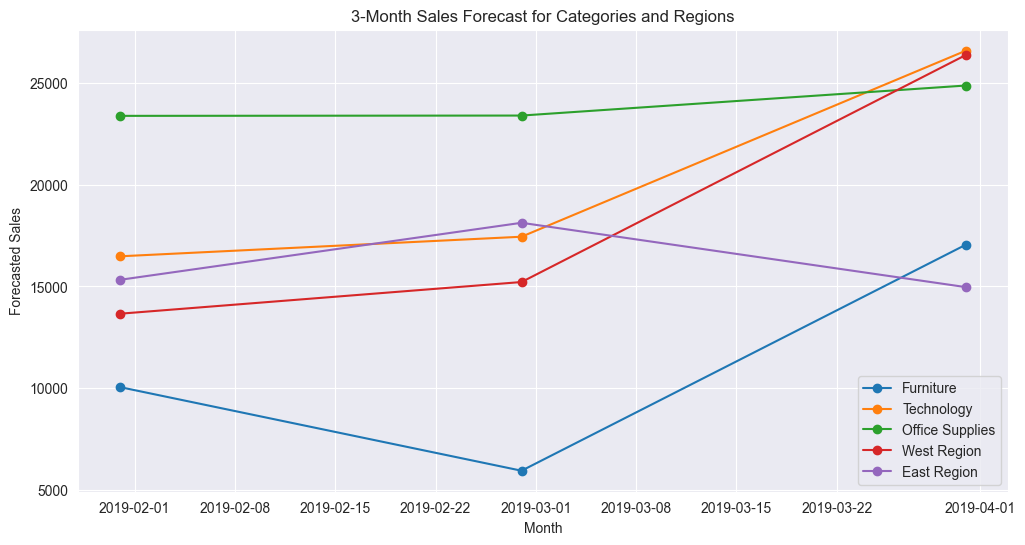


Growth Comparison
Furniture           7001.850098
Technology         10106.519531
Office Supplies     1491.189941
West Region        12715.490234
East Region         -360.140015
dtype: float32

Conclusion
Based on the XGBoost forecasts, the West Region is expected to show the strongest sales growth during the next three months.
This segment has the highest increase in forecasted sales compared to the others.


In [23]:
# TASK-4
# Importing required libraries

from xgboost import XGBRegressor

# Function to prepare data and forecast next 3 months

def forecast_segment(data, name):

    # Converting monthly sales into a dataframe
    ts = data.to_frame()
    ts.columns = ["Sales"]

    # Creating lag features
    ts["Lag_1"] = ts["Sales"].shift(1)
    ts["Lag_2"] = ts["Sales"].shift(2)
    ts["Lag_3"] = ts["Sales"].shift(3)

    # Creating rolling mean
    ts["Rolling_Mean"] = ts["Sales"].rolling(3).mean()

    # Extracting time features
    ts["Month"] = ts.index.month
    ts["Quarter"] = ts.index.quarter

    # Creating season feature
    def get_season(month):

        if month in [12, 1, 2]:
            return 1

        elif month in [3, 4, 5]:
            return 2

        elif month in [6, 7, 8]:
            return 3

        else:
            return 4

    ts["Season"] = ts["Month"].apply(get_season)

    # Removing missing values
    ts = ts.dropna()

    # Training on all available data except last 3 months
    train = ts[:-3]

    X_train = train.drop("Sales", axis=1)
    y_train = train["Sales"]

    # Training XGBoost model
    model = XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )

    model.fit(X_train, y_train)

    # Starting with last known values
    history = list(ts["Sales"])

    future_dates = pd.date_range(
        start=ts.index[-1] + pd.offsets.MonthEnd(1),
        periods=3,
        freq="ME"
    )

    predictions = []

    # Predicting next 3 months one by one
    for date in future_dates:

        lag1 = history[-1]
        lag2 = history[-2]
        lag3 = history[-3]

        rolling = np.mean(history[-3:])

        month = date.month
        quarter = date.quarter

        if month in [12, 1, 2]:
            season = 1
        elif month in [3, 4, 5]:
            season = 2
        elif month in [6, 7, 8]:
            season = 3
        else:
            season = 4

        sample = pd.DataFrame({
            "Lag_1":[lag1],
            "Lag_2":[lag2],
            "Lag_3":[lag3],
            "Rolling_Mean":[rolling],
            "Month":[month],
            "Quarter":[quarter],
            "Season":[season]
        })

        pred = model.predict(sample)[0]

        predictions.append(pred)

        history.append(pred)

    forecast = pd.Series(predictions, index=future_dates)

    print("\n", "-"*50)
    print(name)
    print("-"*50)
    print(forecast.round(2))

    return forecast


# Creating monthly sales for each segment

furniture = (
    df[df["Category"] == "Furniture"]
    .groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
    .sum()
)

technology = (
    df[df["Category"] == "Technology"]
    .groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
    .sum()
)

office = (
    df[df["Category"] == "Office Supplies"]
    .groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
    .sum()
)

west = (
    df[df["Region"] == "West"]
    .groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
    .sum()
)

east = (
    df[df["Region"] == "East"]
    .groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
    .sum()
)

# Forecasting each segment

furniture_forecast = forecast_segment(furniture, "Furniture")

technology_forecast = forecast_segment(technology, "Technology")

office_forecast = forecast_segment(office, "Office Supplies")

west_forecast = forecast_segment(west, "West Region")

east_forecast = forecast_segment(east, "East Region")

# Plotting all forecasts together

plt.figure(figsize=(12,6))

plt.plot(furniture_forecast.index,
         furniture_forecast.values,
         marker="o",
         label="Furniture")

plt.plot(technology_forecast.index,
         technology_forecast.values,
         marker="o",
         label="Technology")

plt.plot(office_forecast.index,
         office_forecast.values,
         marker="o",
         label="Office Supplies")

plt.plot(west_forecast.index,
         west_forecast.values,
         marker="o",
         label="West Region")

plt.plot(east_forecast.index,
         east_forecast.values,
         marker="o",
         label="East Region")

plt.title("3-Month Sales Forecast for Categories and Regions")
plt.xlabel("Month")
plt.ylabel("Forecasted Sales")
plt.grid(True)
plt.legend()
# Save and show
plt.savefig('charts/4_category_region_forecasts.png', bbox_inches='tight', dpi=300)
plt.show()

# Finding which segment has highest growth

growth = {

    "Furniture": furniture_forecast.iloc[-1] - furniture_forecast.iloc[0],

    "Technology": technology_forecast.iloc[-1] - technology_forecast.iloc[0],

    "Office Supplies": office_forecast.iloc[-1] - office_forecast.iloc[0],

    "West Region": west_forecast.iloc[-1] - west_forecast.iloc[0],

    "East Region": east_forecast.iloc[-1] - east_forecast.iloc[0]

}

growth = pd.Series(growth)

print("\nGrowth Comparison")
print(growth.round(2))

best_growth = growth.idxmax()

print("\nConclusion")
print("Based on the XGBoost forecasts, the", best_growth,
      "is expected to show the strongest sales growth during the next three months.")
print("This segment has the highest increase in forecasted sales compared to the others.")

In [24]:
# Saving forecast results for Streamlit Dashboard

forecast_results = pd.DataFrame({

    "Type": [
        "Category",
        "Category",
        "Category",
        "Region",
        "Region"
    ],

    "Name": [
        "Furniture",
        "Technology",
        "Office Supplies",
        "West Region",
        "East Region"
    ],

    "Month 1 Forecast": [
        furniture_forecast.iloc[0],
        technology_forecast.iloc[0],
        office_forecast.iloc[0],
        west_forecast.iloc[0],
        east_forecast.iloc[0]
    ],

    "Month 2 Forecast": [
        furniture_forecast.iloc[1],
        technology_forecast.iloc[1],
        office_forecast.iloc[1],
        west_forecast.iloc[1],
        east_forecast.iloc[1]
    ],

    "Month 3 Forecast": [
        furniture_forecast.iloc[2],
        technology_forecast.iloc[2],
        office_forecast.iloc[2],
        west_forecast.iloc[2],
        east_forecast.iloc[2]
    ],

    "MAE": [
        xgb_mae,
        xgb_mae,
        xgb_mae,
        xgb_mae,
        xgb_mae
    ],

    "RMSE": [
        xgb_rmse,
        xgb_rmse,
        xgb_rmse,
        xgb_rmse,
        xgb_rmse
    ]

})

forecast_results.to_csv("forecast_results.csv", index=False)

print("\nforecast_results.csv has been created successfully.")
print(forecast_results)




forecast_results.csv has been created successfully.
       Type             Name  Month 1 Forecast  Month 2 Forecast  \
0  Category        Furniture      10048.811523       5941.170898   
1  Category       Technology      16483.417969      17445.609375   
2  Category  Office Supplies      23387.363281      23402.376953   
3    Region      West Region      13661.606445      15218.239258   
4    Region      East Region      15328.649414      18130.501953   

   Month 3 Forecast           MAE          RMSE  
0      17050.664062  13915.321042  18893.847269  
1      26589.939453  13915.321042  18893.847269  
2      24878.554688  13915.321042  18893.847269  
3      26377.095703  13915.321042  18893.847269  
4      14968.504883  13915.321042  18893.847269  


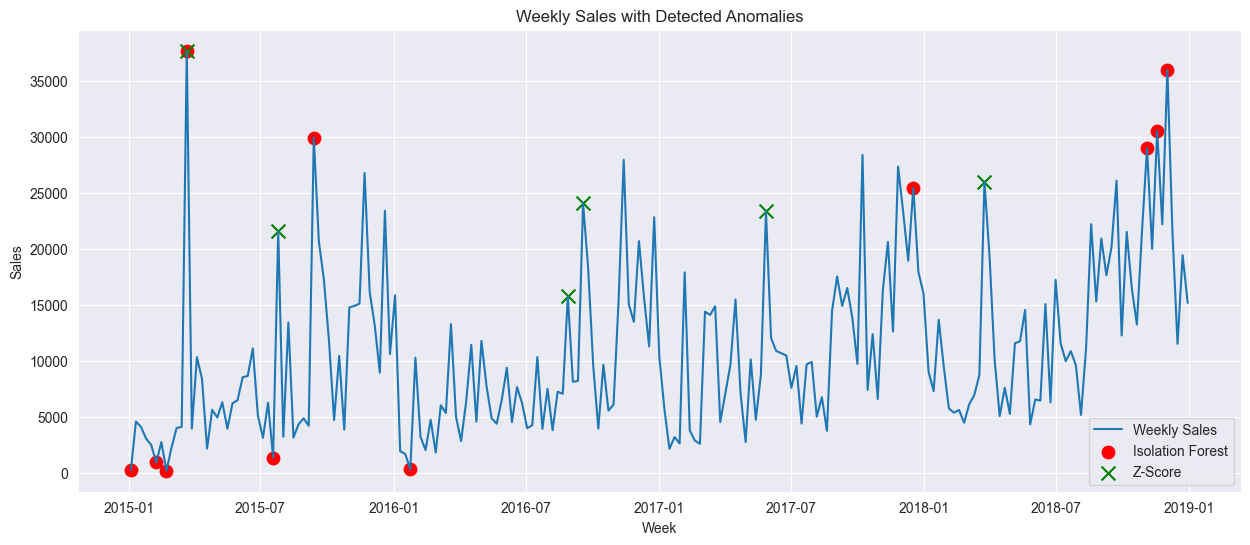

Isolation Forest Anomalies
--------------------------------------------------
          Week      Sales
0   2015-01-04    304.508
5   2015-02-08    968.534
7   2015-02-22    224.912
11  2015-03-22  37703.665
28  2015-07-19   1387.686
36  2015-09-13  29959.137
55  2016-01-24    358.522
154 2017-12-17  25449.800
200 2018-11-04  29017.467
202 2018-11-18  30572.447
204 2018-12-02  35998.900

Z-Score Anomalies
--------------------------------------------------
          Week      Sales
11  2015-03-22  37703.665
29  2015-07-26  21590.080
86  2016-08-28  15773.478
89  2016-09-18  24095.960
125 2017-05-28  23367.662
168 2018-03-25  26029.904

Possible Real-World Explanation
--------------------------------------------------
2015-01-04 : Lower sales may be due to post-holiday demand reduction.
2015-02-08 : SSales may have been affected by promotional campaigns,inventory shortages, or sudden changes in customer demand.
2015-02-22 : SSales may have been affected by promotional campaigns,inventory

In [25]:
#TASK-5
# Importing required libraries

from sklearn.ensemble import IsolationForest

# Creating weekly sales data

weekly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="W"))["Sales"]
      .sum()
      .reset_index()
)

weekly_sales.columns = ["Week", "Sales"]

# ---------------------------------------------------------
# Isolation Forest Anomaly Detection
# ---------------------------------------------------------

# Isolation Forest detects unusual observations without
# needing labelled anomaly data.

iso_model = IsolationForest(
    contamination=0.05,
    random_state=42
)

weekly_sales["Isolation_Result"] = iso_model.fit_predict(
    weekly_sales[["Sales"]]
)

# -1 means anomaly
#  1 means normal point

weekly_sales["Isolation_Anomaly"] = (
    weekly_sales["Isolation_Result"] == -1
)

# ---------------------------------------------------------
# Z-Score Based Anomaly Detection
# ---------------------------------------------------------

# Calculating rolling statistics

weekly_sales["Rolling_Mean"] = (
    weekly_sales["Sales"]
    .rolling(window=8)
    .mean()
)

weekly_sales["Rolling_STD"] = (
    weekly_sales["Sales"]
    .rolling(window=8)
    .std()
)

# Calculating Z-score

weekly_sales["Z_Score"] = (
    (weekly_sales["Sales"] -
     weekly_sales["Rolling_Mean"])
    /
    weekly_sales["Rolling_STD"]
)

# A point is considered an anomaly if
# it is more than 2 standard deviations away
# from the rolling mean.

weekly_sales["Z_Anomaly"] = (
    weekly_sales["Z_Score"].abs() > 2
)

# ---------------------------------------------------------
# Plotting the anomalies
# ---------------------------------------------------------

plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales["Week"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

# Isolation Forest anomalies

plt.scatter(
    weekly_sales.loc[
        weekly_sales["Isolation_Anomaly"],
        "Week"
    ],
    weekly_sales.loc[
        weekly_sales["Isolation_Anomaly"],
        "Sales"
    ],
    color="red",
    marker="o",
    s=80,
    label="Isolation Forest"
)

# Z-score anomalies

plt.scatter(
    weekly_sales.loc[
        weekly_sales["Z_Anomaly"],
        "Week"
    ],
    weekly_sales.loc[
        weekly_sales["Z_Anomaly"],
        "Sales"
    ],
    color="green",
    marker="x",
    s=100,
    label="Z-Score"
)

plt.title("Weekly Sales with Detected Anomalies")
plt.xlabel("Week")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
# Save and show
plt.savefig('charts/5_anomaly_detection.png', bbox_inches='tight', dpi=300)
plt.show()

# Printing detected anomalies

print("Isolation Forest Anomalies")
print("-"*50)

print(
    weekly_sales.loc[
        weekly_sales["Isolation_Anomaly"],
        ["Week","Sales"]
    ]
)

print("\nZ-Score Anomalies")
print("-"*50)

print(
    weekly_sales.loc[
        weekly_sales["Z_Anomaly"],
        ["Week","Sales"]
    ]
)

# Possible explanations

print("\nPossible Real-World Explanation")
print("-"*50)

for index, row in weekly_sales.loc[
    weekly_sales["Isolation_Anomaly"]
].iterrows():

    month = row["Week"].month

    if month in [10,11,12]:

        reason = "High sales may be due to festive season, holiday shopping or promotional offers."

    elif month == 1:

        reason = "Lower sales may be due to post-holiday demand reduction."

    else:

        reason = "SSales may have been affected by promotional campaigns,inventory shortages, or sudden changes in customer demand."

    print(row["Week"].date(), ":", reason)

# Comparing both methods

common = weekly_sales[
    weekly_sales["Isolation_Anomaly"] &
    weekly_sales["Z_Anomaly"]
]

only_iso = weekly_sales[
    weekly_sales["Isolation_Anomaly"] &
    (~weekly_sales["Z_Anomaly"])
]

only_z = weekly_sales[
    weekly_sales["Z_Anomaly"] &
    (~weekly_sales["Isolation_Anomaly"])
]

print("\nComparison of Both Methods")
print("-"*50)

print("Number of anomalies detected by both methods :", len(common))

print("Number detected only by Isolation Forest :", len(only_iso))

print("Number detected only by Z-Score :", len(only_z))


# Final observations

print("\nObservations")
print("-"*50)

print("1. Isolation Forest detected both unusually high and unusually low sales weeks using a machine learning approach.")

print("2. Z-Score detected weeks where sales were far from the rolling average based on statistical deviation.")

print("3. Only one anomaly was detected by both methods, while several anomalies were unique to each method.")

print("4. This shows that the two techniques use different approaches for detecting anomalies. Isolation Forest captures more complex patterns, whereas Z-Score mainly identifies extreme statistical values.")

In [26]:
# ---------------------------------------------------------
# Saving anomaly results for Streamlit Dashboard
# ---------------------------------------------------------

# Keeping only the required columns

anomaly_results = weekly_sales[
    [
        "Week",
        "Sales",
        "Isolation_Anomaly",
        "Z_Anomaly"
    ]
].copy()

# Creating a readable status column

anomaly_results["Detection"] = "Normal"

anomaly_results.loc[
    anomaly_results["Isolation_Anomaly"] &
    anomaly_results["Z_Anomaly"],
    "Detection"
] = "Both Methods"

anomaly_results.loc[
    anomaly_results["Isolation_Anomaly"] &
    (~anomaly_results["Z_Anomaly"]),
    "Detection"
] = "Isolation Forest"

anomaly_results.loc[
    (~anomaly_results["Isolation_Anomaly"]) &
    anomaly_results["Z_Anomaly"],
    "Detection"
] = "Z-Score"

# Keeping only detected anomalies

anomaly_results = anomaly_results[
    anomaly_results["Detection"] != "Normal"
]

# Saving the file

anomaly_results.to_csv(
    "anomaly_results.csv",
    index=False
)

print("\nanomaly_results.csv created successfully.\n")

print(anomaly_results)


anomaly_results.csv created successfully.

          Week      Sales  Isolation_Anomaly  Z_Anomaly         Detection
0   2015-01-04    304.508               True      False  Isolation Forest
5   2015-02-08    968.534               True      False  Isolation Forest
7   2015-02-22    224.912               True      False  Isolation Forest
11  2015-03-22  37703.665               True       True      Both Methods
28  2015-07-19   1387.686               True      False  Isolation Forest
29  2015-07-26  21590.080              False       True           Z-Score
36  2015-09-13  29959.137               True      False  Isolation Forest
55  2016-01-24    358.522               True      False  Isolation Forest
86  2016-08-28  15773.478              False       True           Z-Score
89  2016-09-18  24095.960              False       True           Z-Score
125 2017-05-28  23367.662              False       True           Z-Score
154 2017-12-17  25449.800               True      False  Isolation F

Feature Table
------------------------------------------------------------
              Total Sales  Growth Rate   Volatility  Average Order Value
Sub-Category                                                            
Accessories   164186.7000   145.055961  2579.994809           217.178175
Appliances    104618.4030   165.242912  1821.621539           227.926804
Art            26705.4100    49.649531   330.488343            34.019631
Binders       200028.7850    65.778638  3848.223648           134.067550
Bookcases     113813.1987    49.846598  2220.405080           503.598224
Chairs        322822.7310    20.954677  4407.232960           531.833165
Copiers       146248.0940   479.729510  5500.774391          2215.880212
Envelopes      16128.0460   -12.121345   228.218688            65.032444
Fasteners       3001.9600    30.468364    48.742229            14.027850
Furnishings    89212.0180   106.824969  1360.017867            95.823865
Labels         12347.7260    36.073373   223.4712

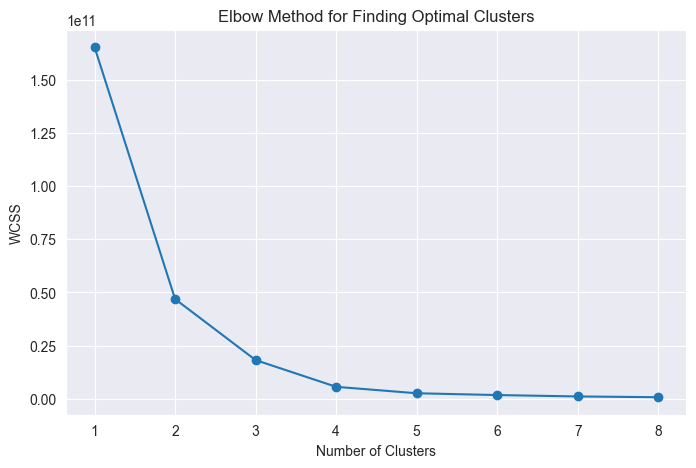


Observation
------------------------------------------------------------
Choose the value of K where the curve starts flattening.
That point is considered the optimal number of clusters.


In [27]:
#TASK-6-A
# Importing required libraries

from sklearn.cluster import KMeans

# ---------------------------------------------------------
# Creating features for each product sub-category
# ---------------------------------------------------------

# Monthly sales for every sub-category
monthly_sales = (
    df.groupby([
        "Sub-Category",
        pd.Grouper(key="Order Date", freq="ME")
    ])["Sales"]
    .sum()
    .reset_index()
)

# Total sales volume
total_sales = (
    df.groupby("Sub-Category")["Sales"]
    .sum()
)

# Average order value
avg_order_value = (
    df.groupby("Sub-Category")["Sales"]
    .mean()
)

# Sales volatility (standard deviation of monthly sales)
sales_volatility = (
    monthly_sales.groupby("Sub-Category")["Sales"]
    .std()
)

# Calculating Year-over-Year Growth

# Sales by year for every sub-category
yearly_sales = (
    df.groupby([
        "Sub-Category",
        "Year"
    ])["Sales"]
    .sum()
    .unstack(fill_value=0)
)

# Growth = (Last Year - First Year) / First Year

growth_rate = (
    (yearly_sales.iloc[:, -1] - yearly_sales.iloc[:, 0])
    /
    yearly_sales.iloc[:, 0]
) * 100

# Combining all features into one dataframe

cluster_data = pd.DataFrame({

    "Total Sales": total_sales,

    "Growth Rate": growth_rate,

    "Volatility": sales_volatility,

    "Average Order Value": avg_order_value

})

# Filling any missing values
cluster_data = cluster_data.fillna(0)

print("Feature Table")
print("-"*60)

print(cluster_data)

# Elbow Method

wcss = []

for k in range(1, 9):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(cluster_data)

    wcss.append(model.inertia_)

# Printing WCSS values

print("\nWCSS Values")
print("-"*60)

for i in range(len(wcss)):
    print("Clusters =", i+1, "  WCSS =", round(wcss[i],2))

# Plotting the Elbow Curve

plt.figure(figsize=(8,5))

plt.plot(
    range(1,9),
    wcss,
    marker="o"
)

plt.title("Elbow Method for Finding Optimal Clusters")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.grid(True)

plt.show()

print("\nObservation")
print("-"*60)
print("Choose the value of K where the curve starts flattening.")
print("That point is considered the optimal number of clusters.")

Cluster Summary
------------------------------------------------------------
           Total Sales  Growth Rate   Volatility  Average Order Value
Cluster                                                              
0        186976.038333   122.035852  3929.785735           853.701142
1         20920.690000    23.069192   571.202923            79.990335
2        325302.589500    28.256142  4229.975590           453.007021
3         96117.980925   103.454112  1606.717367           221.192288


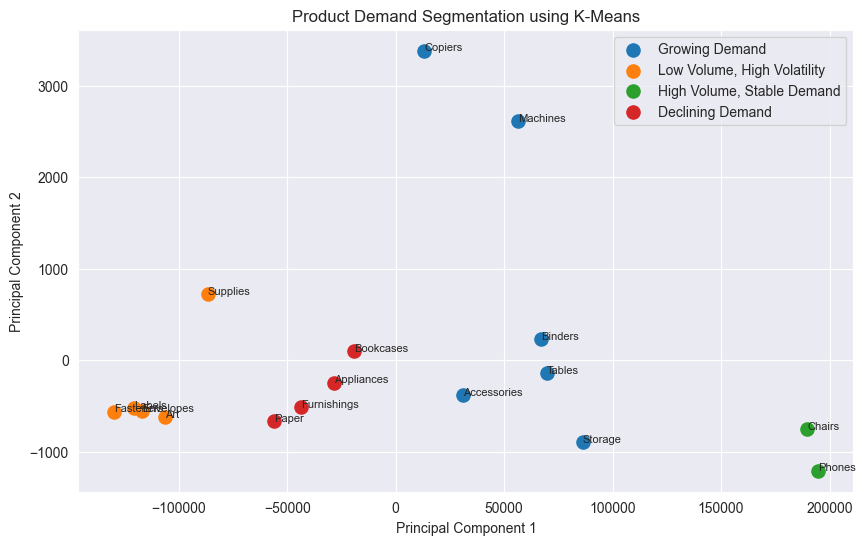


Demand Segmentation
------------------------------------------------------------
              Total Sales  Growth Rate   Volatility  Average Order Value  \
Sub-Category                                                               
Accessories   164186.7000   145.055961  2579.994809           217.178175   
Appliances    104618.4030   165.242912  1821.621539           227.926804   
Art            26705.4100    49.649531   330.488343            34.019631   
Binders       200028.7850    65.778638  3848.223648           134.067550   
Bookcases     113813.1987    49.846598  2220.405080           503.598224   
Chairs        322822.7310    20.954677  4407.232960           531.833165   
Copiers       146248.0940   479.729510  5500.774391          2215.880212   
Envelopes      16128.0460   -12.121345   228.218688            65.032444   
Fasteners       3001.9600    30.468364    48.742229            14.027850   
Furnishings    89212.0180   106.824969  1360.017867            95.823865   
Labels

In [28]:
#TASK6-B
# Importing required libraries

from sklearn.decomposition import PCA

# ---------------------------------------------------------
# Applying K-Means Clustering
# ---------------------------------------------------------

# Using only the numeric features for clustering

features = cluster_data[
    ["Total Sales", "Growth Rate", "Volatility", "Average Order Value"]
]

# Using K = 4 from the Elbow Method

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster_data["Cluster"] = kmeans.fit_predict(features)

# ---------------------------------------------------------
# Viewing cluster summary
# ---------------------------------------------------------

cluster_summary = cluster_data.groupby("Cluster").mean()

print("Cluster Summary")
print("-"*60)
print(cluster_summary)

# ---------------------------------------------------------
# Giving meaningful names
# ---------------------------------------------------------

cluster_names = {
    0: "Growing Demand",
    1: "Low Volume, High Volatility",
    2: "High Volume, Stable Demand",
    3: "Declining Demand"
}

cluster_data["Demand Group"] = cluster_data["Cluster"].map(cluster_names)

# Applying PCA for visualization

pca = PCA(n_components=2)

pca_result = pca.fit_transform(features)

cluster_data["PCA1"] = pca_result[:,0]

cluster_data["PCA2"] = pca_result[:,1]

# Plotting the clusters

plt.figure(figsize=(10,6))

for cluster in sorted(cluster_data["Cluster"].unique()):

    temp = cluster_data[cluster_data["Cluster"] == cluster]

    plt.scatter(
        temp["PCA1"],
        temp["PCA2"],
        s=90,
        label=cluster_names[cluster]
    )

    for index, row in temp.iterrows():

        plt.annotate(
            index,
            (row["PCA1"], row["PCA2"]),
            fontsize=8
        )

plt.title("Product Demand Segmentation using K-Means")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)
# Save and show
plt.savefig('charts/6_product_clusters.png', bbox_inches='tight', dpi=300)
plt.show()

# Printing final segmentation

print("\nDemand Segmentation")
print("-"*60)

print(
    cluster_data[
        [
            "Total Sales",
            "Growth Rate",
            "Volatility",
            "Average Order Value",
            "Demand Group"
        ]
    ]
)

# Recommended Stocking Strategy

print("\nRecommended Stocking Strategy")
print("-"*60)

print("\nHigh Volume, Stable Demand")
print("Maintain high inventory because these products have consistently strong demand.")

print("\nGrowing Demand")
print("Gradually increase inventory to meet the increasing demand.")

print("\nLow Volume, High Volatility")
print("Keep moderate inventory and monitor sales regularly.")

print("\nDeclining Demand")
print("Reduce inventory and avoid overstocking.")

# Final observations

print("\nObservations")
print("-"*60)

print("1. Product sub-categories were grouped using Total Sales, Growth Rate, Volatility and Average Order Value.")

print("2. K-Means clustering divided the products into four demand segments.")

print("3. PCA reduced the four features into two dimensions for easy visualization.")

print("4. Products with high and stable demand should always be sufficiently stocked.")

print("5. Products with declining demand should be stocked cautiously to avoid excess inventory.")

In [29]:
# Saving cluster results for Streamlit Dashboard

# Selecting useful columns

cluster_results = cluster_data[
    [
        "Total Sales",
        "Growth Rate",
        "Volatility",
        "Average Order Value",
        "Cluster",
        "Demand Group",
        "PCA1",
        "PCA2"
    ]
].copy()

# Keeping Sub-Category as a normal column

cluster_results.reset_index(inplace=True)

# Saving to CSV

cluster_results.to_csv(
    "cluster_results.csv",
    index=False
)

print("\ncluster_results.csv created successfully.\n")

print(cluster_results)


cluster_results.csv created successfully.

   Sub-Category  Total Sales  Growth Rate   Volatility  Average Order Value  \
0   Accessories  164186.7000   145.055961  2579.994809           217.178175   
1    Appliances  104618.4030   165.242912  1821.621539           227.926804   
2           Art   26705.4100    49.649531   330.488343            34.019631   
3       Binders  200028.7850    65.778638  3848.223648           134.067550   
4     Bookcases  113813.1987    49.846598  2220.405080           503.598224   
5        Chairs  322822.7310    20.954677  4407.232960           531.833165   
6       Copiers  146248.0940   479.729510  5500.774391          2215.880212   
7     Envelopes   16128.0460   -12.121345   228.218688            65.032444   
8     Fasteners    3001.9600    30.468364    48.742229            14.027850   
9   Furnishings   89212.0180   106.824969  1360.017867            95.823865   
10       Labels   12347.7260    36.073373   223.471218            34.587468   
11     M